Import Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb

import warnings
warnings.filterwarnings("ignore")
RANDOM_STATE = 42


Load Dataset

In [10]:
df = pd.read_csv("synthetic_food_dataset_imbalanced.csv")  # adjust path if needed
df.head()

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size,Meal_Type,Preparation_Method,Is_Vegan,Is_Gluten_Free,Food_Name
0,290.463673,14.340084,14.152608,35.266644,4.828030,1.291432,647.553389,24.990309,81.575896,45.669118,197.570043,dinner,fried,False,False,Pizza
1,212.626748,4.080908,11.621584,23.218957,16.347814,0.130303,68.572414,34.301652,69.522492,49.854415,103.833510,snack,raw,False,True,Ice Cream
2,330.695408,14.326708,19.747680,29.479164,6.251137,0.794477,663.171859,34.816834,62.552384,40.132866,198.989367,snack,raw,False,False,Burger
3,198.070798,9.452445,5.475896,32.097878,2.984621,1.710468,300.749543,28.510998,68.688853,57.423461,135.714202,lunch,fried,False,True,Sushi
4,274.496228,6.099547,16.256002,29.756638,17.352958,1.465676,296.314958,15.403173,70.385059,33.170460,73.019474,snack,baked,False,False,Donut


EDA

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31700 entries, 0 to 31699
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Calories            31325 non-null  float64
 1   Protein             31325 non-null  float64
 2   Fat                 31325 non-null  float64
 3   Carbs               31325 non-null  float64
 4   Sugar               31325 non-null  float64
 5   Fiber               31325 non-null  float64
 6   Sodium              31325 non-null  float64
 7   Cholesterol         31325 non-null  float64
 8   Glycemic_Index      31325 non-null  float64
 9   Water_Content       31325 non-null  float64
 10  Serving_Size        31325 non-null  float64
 11  Meal_Type           31700 non-null  object 
 12  Preparation_Method  31700 non-null  object 
 13  Is_Vegan            31700 non-null  bool   
 14  Is_Gluten_Free      31700 non-null  bool   
 15  Food_Name           31700 non-null  object 
dtypes: b

In [12]:
df.describe()

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size
count,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000
mean,273.378441,9.523802,12.476848,28.943200,8.543813,1.904044,335.387611,26.865167,64.213509,48.976592,150.731940
std,111.457160,8.024212,8.425834,12.668795,7.989075,1.779542,319.066106,24.965067,25.390239,20.738749,51.796599
min,60.786204,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.465039,58.575705
25%,210.301731,3.858307,8.245636,25.098800,3.739656,0.741204,63.000654,12.701920,59.984731,38.994221,109.511113
50%,281.774249,9.091637,11.574161,29.681430,5.500479,1.646608,292.525242,23.285882,68.436204,45.613748,151.706514
75%,329.821946,12.683957,15.818611,34.635789,14.426303,2.668750,631.367901,35.132214,75.464697,52.399496,189.083806
max,1289.956763,81.761772,88.619611,140.585537,78.548162,18.891993,2724.236846,260.149443,286.126400,251.837472,554.719629


In [13]:
df.isnull().sum()

Calories              375
Protein               375
Fat                   375
Carbs                 375
Sugar                 375
Fiber                 375
Sodium                375
Cholesterol           375
Glycemic_Index        375
Water_Content         375
Serving_Size          375
Meal_Type               0
Preparation_Method      0
Is_Vegan                0
Is_Gluten_Free          0
Food_Name               0
dtype: int64

Class Distribution

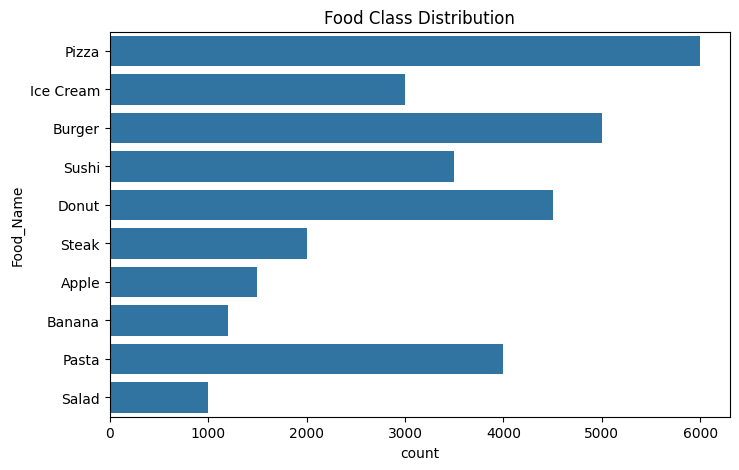

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(y=df['Food_Name'])
plt.title("Food Class Distribution")
plt.show()

Correlation Heatmap (Numeric Only)

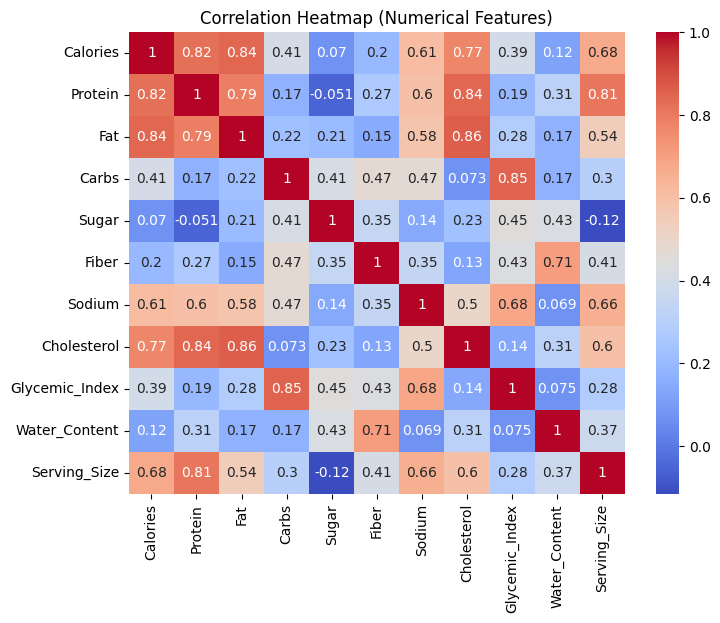

In [16]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

DATA PREPROCESSING

Handle Missing Values

In [18]:
print("Missing Values:\n", df.isnull().sum())

df = df.dropna()
print("After dropping missing:", df.shape)

Missing Values:
 Calories              0
Protein               0
Fat                   0
Carbs                 0
Sugar                 0
Fiber                 0
Sodium                0
Cholesterol           0
Glycemic_Index        0
Water_Content         0
Serving_Size          0
Meal_Type             0
Preparation_Method    0
Is_Vegan              0
Is_Gluten_Free        0
Food_Name             0
dtype: int64
After dropping missing: (31260, 16)


Convert Boolean to Integer

In [19]:
df["Is_Vegan"] = df["Is_Vegan"].astype(int)
df["Is_Gluten_Free"] = df["Is_Gluten_Free"].astype(int)

One-Hot Encode Categorical Features

In [20]:
df = pd.get_dummies(df, columns=["Meal_Type", "Preparation_Method"], drop_first=True)

Split Features and Target

In [21]:
X = df.drop("Food_Name", axis=1)
y = df["Food_Name"]

Encode Target Variable

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Scale Features

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Train Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

MODEL TRAINING

Define Models

In [28]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "XGBoost": xgb.XGBClassifier(eval_metric='mlogloss'),
    "Gradient Boosting": GradientBoostingClassifier()
}

Train & Evaluate Models

In [29]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results.append([name, acc])

    print("\n", "="*40)
    print(name)
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.9942418426103646
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       294
           1       0.98      0.99      0.99       237
           2       0.98      0.99      0.99       984
           3       1.00      1.00      1.00       891
           4       1.00      0.99      0.99       591
           5       1.00      1.00      1.00       792
           6       1.00      0.99      0.99      1180
           7       1.00      0.99      1.00       197
           8       0.99      1.00      1.00       396
           9       0.99      1.00      1.00       690

    accuracy                           0.99      6252
   macro avg       0.99      0.99      0.99      6252
weighted avg       0.99      0.99      0.99      6252


Decision Tree
Accuracy: 0.988003838771593
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       294
           1       0.98      0.98      

Model Comparison

In [31]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
6,Gradient Boosting,0.994722
4,SVM,0.994562
5,XGBoost,0.994562
0,Logistic Regression,0.994242
2,Random Forest,0.994242
3,KNN,0.992003
1,Decision Tree,0.988004


Train Best Model (Example: Random Forest)

In [32]:
best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("Best Model Accuracy:", accuracy_score(y_test, y_pred))

Best Model Accuracy: 0.9942418426103646


Confusion Matrix

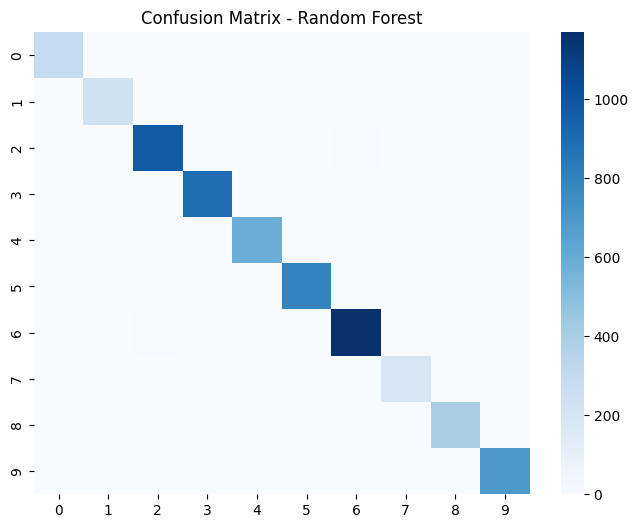

In [33]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=False,
            cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

REAL-TIME FOOD PREDICTION

In [35]:
def predict_food(input_data):
    
    input_array = np.array(input_data).reshape(1, -1)
    input_scaled = scaler.transform(input_array)
    prediction = best_model.predict(input_scaled)
    return le.inverse_transform(prediction)[0]

In [43]:
sample_input = X.iloc[0].values 
predict_food(sample_input)

'Pizza'